Loading raw datasets...


C:\Users\anwes\AppData\Local\Temp\ipykernel_15860\1042287533.py:7: DtypeWarning: Columns (0: satellite, 1: instrument, 2: confidence, 3: version, 4: daynight) have mixed types. Specify dtype option on import or set low_memory=False.
  firms_df = pd.read_csv('../data/firms_raw.csv')


GDELT Events: 233335 | FIRMS Anomalies: 155703
Running spatial cross-join (50km radius, ±2 days)...

Anchored 998 out of 1000 tested events (99.8%)


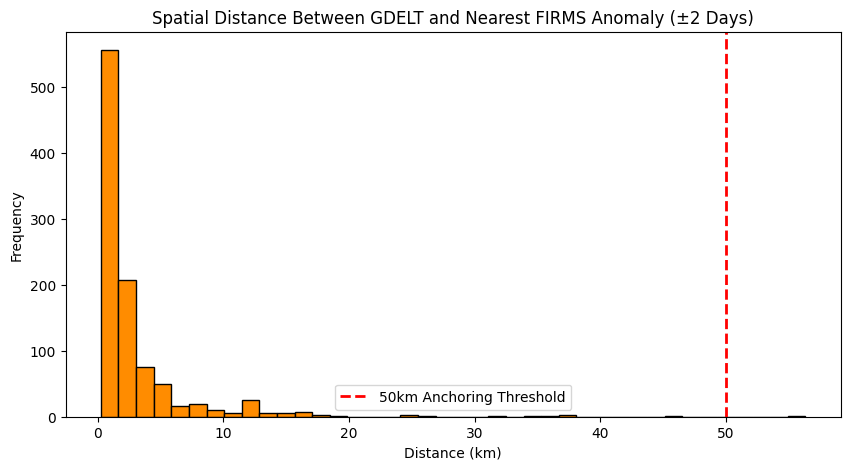

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loading raw datasets...")
gdelt_df = pd.read_csv('../data/gdelt_kinetic_raw.csv')
firms_df = pd.read_csv('../data/firms_raw.csv')

# 1. Clean Dates and Apply the 6-Day Lag
gdelt_df['date'] = pd.to_datetime(gdelt_df['date']) - pd.Timedelta(days=6)
firms_df['date'] = pd.to_datetime(firms_df['acq_date'] if 'acq_date' in firms_df.columns else firms_df['date'])

# Drop rows without coordinates
gdelt_df = gdelt_df.dropna(subset=['action_lat', 'action_lon'])
firms_df = firms_df.dropna(subset=['latitude', 'longitude'])

print(f"GDELT Events: {len(gdelt_df)} | FIRMS Anomalies: {len(firms_df)}")

# 2. Haversine Distance Function (Vectorized)
def haversine_vectorized(lat1, lon1, lat2_series, lon2_series):
    R = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2_series), np.radians(lon2_series)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# 3. Spatial Anchoring Logic
anchored_count = 0
spatial_errors = []

print("Running spatial cross-join (50km radius, ±2 days)...")
# For testing speed, we'll sample the first 1000 events
for idx, g_row in gdelt_df.head(1000).iterrows():
    # Filter FIRMS to within ±2 days of the GDELT event
    time_mask = (firms_df['date'] >= g_row['date'] - pd.Timedelta(days=2)) & \
                (firms_df['date'] <= g_row['date'] + pd.Timedelta(days=2))
    
    temporal_firms = firms_df[time_mask]
    
    if temporal_firms.empty:
        continue
        
    # Calculate distances to all temporal matches
    distances = haversine_vectorized(
        g_row['action_lat'], g_row['action_lon'], 
        temporal_firms['latitude'], temporal_firms['longitude']
    )
    
    min_dist = distances.min()
    spatial_errors.append(min_dist)
    
    # If within 50km, we consider it anchored!
    if min_dist <= 50.0:
        anchored_count += 1

# 4. Results
print(f"\nAnchored {anchored_count} out of 1000 tested events ({(anchored_count/1000)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.hist([d for d in spatial_errors if d <= 200], bins=40, color='darkorange', edgecolor='black')
plt.axvline(50, color='red', linestyle='dashed', linewidth=2, label='50km Anchoring Threshold')
plt.title('Spatial Distance Between GDELT and Nearest FIRMS Anomaly (±2 Days)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.legend()
plt.show()